# CatBoost 하이퍼 파라미터 튜닝

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. 데이터 로드

In [2]:
X = pd.read_csv('../../../data/preprocessed/cell2cell_train.csv')
y = pd.read_csv('../../../data/preprocessed/cell2cell_train_churn.csv')

X.drop('CustomerID', axis=1)

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,Occ_Clerical,Occ_Crafts,Occ_Homemaker,Occ_Other,Occ_Professional,Occ_Retired,Occ_Self,Occ_Student,Marital_No,Marital_Yes
0,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,...,0,0,0,0,1,0,0,0,1,0
1,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,...,0,0,0,0,1,0,0,0,0,1
2,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,1
3,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,...,0,0,0,1,0,0,0,0,1,0
4,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49771,0.00,76.0,30.0,0.00,0.0,0.0,0.0,0.0,5.7,1.0,...,0,0,0,0,1,0,0,0,1,0
49772,31.92,63.0,17.0,0.00,43.0,0.0,-38.0,-13.2,0.7,0.0,...,0,0,0,1,0,0,0,0,0,1
49773,71.99,724.0,70.0,0.00,4.0,0.9,-40.0,-2.0,14.3,1.0,...,0,0,0,0,1,0,0,0,0,0
49774,117.49,384.0,30.0,0.00,250.0,0.0,0.0,0.0,4.0,1.0,...,0,0,0,0,1,0,0,0,0,1


### 2. 데이터 분리 및 모델 훈련용 전처리

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y, test_size=0.2)

In [4]:
numeric_features = [
    'MonthlyRevenue', 'TotalRecurringCharge', 'PercChangeRevenues',
    'MonthlyMinutes', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes',
    'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls',
    'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls',
    'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls',
    'CallWaitingCalls', 'DirectorAssistedCalls', 'MonthsInService', 'CurrentEquipmentDays',
    'AgeHH1', 'AgeHH2'
]


cat_features = [
    'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 
    'RVOwner', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 
    'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'RetentionCalls', 
    'RetentionOffersAccepted', 'NewCellphoneUser', 'NotNewCellphoneUser', 
    'ReferralsMadeBySubscriber', 'IncomeGroup', 'OwnsMotorcycle', 
    'AdjustmentsToCreditRating', 'HandsetPrice', 'MadeCallToRetentionTeam', 
    'CreditRating', 'Prizm_Other', 'Prizm_Rural', 'Prizm_Suburban', 'Prizm_Town', 
    'Occ_Clerical', 'Occ_Crafts', 'Occ_Homemaker', 'Occ_Other', 'Occ_Professional', 
    'Occ_Retired', 'Occ_Self', 'Occ_Student', 'Marital_No', 'Marital_Yes',
    'UniqueSubs', 'ActiveSubs', 'Handsets', 'HandsetModels'
]

In [5]:
for col in cat_features:
    X_train[col] = X_train[col].astype(int)

for col in cat_features:
    X_test[col] = X_test[col].astype(int)

In [6]:
from catboost import Pool

X_train_pool = Pool(X_train, y_train, cat_features=cat_features)
X_test_pool = Pool(X_test, y_test, cat_features=cat_features)

### 3. 하이퍼 파라미터 튜닝

In [ ]:
import optuna
from catboost import CatBoostClassifier

def objective(trial):
    params = {
        'iterations': 1000,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'verbose': False,
        'early_stopping_rounds': 50,
        'auto_class_weights': 'Balanced',
        # 튜닝할 파라미터 범위 설정
        'depth': trial.suggest_int('depth', 4, 10),                                  # 트리의 깊이
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True), # 학습률 (로그 스케일)
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),                    # L2 정규화
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10, log=True), # 랜덤성 부여
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0), # 배깅 강도
        'rsm': trial.suggest_float('rsm', 0.5, 1.0),                                 # 피처 샘플링 비율
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),           # 리프 노드 최소 데이터 수
    }
    
    # 모델 생성 및 학습
    model = CatBoostClassifier(**params, cat_features=cat_features)
    
    model.fit(
        X_train_pool, 
        eval_set=X_test_pool,
        verbose=False
    )
    
    # 평가 점수 반환 (CatBoost는 내부적으로 best_score_에 최고 점수를 저장함)
    # 'validation'은 eval_set에 넣은 데이터셋 이름 (기본값)
    best_auc = model.best_score_['validation']['AUC']
    
    return best_auc

# 3. 스터디 생성 및 최적화 실행
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

# 4. 결과 확인
print("Best AUC:", study.best_value)
print("Best params:", study.best_params)

[I 2026-02-23 23:23:04,121] A new study created in memory with name: no-name-b700a2f2-8672-4832-b338-9006be3a5074
[I 2026-02-23 23:23:49,673] Trial 0 finished with value: 0.6632432501532037 and parameters: {'depth': 7, 'learning_rate': 0.0015666115013860786, 'l2_leaf_reg': 8.891481498185517, 'random_strength': 2.922726413439308e-09, 'bagging_temperature': 0.8275289752749788, 'rsm': 0.5456434445896949, 'min_data_in_leaf': 31}. Best is trial 0 with value: 0.6632432501532037.
[I 2026-02-23 23:23:55,173] Trial 1 finished with value: 0.642899438160987 and parameters: {'depth': 4, 'learning_rate': 0.0020876234202245984, 'l2_leaf_reg': 3.878852702798811, 'random_strength': 3.836354934833581e-08, 'bagging_temperature': 0.12128975886768745, 'rsm': 0.5180868408778756, 'min_data_in_leaf': 67}. Best is trial 0 with value: 0.6632432501532037.
[I 2026-02-23 23:24:27,682] Trial 2 finished with value: 0.6779555677697333 and parameters: {'depth': 10, 'learning_rate': 0.03615664999511582, 'l2_leaf_reg':

Best AUC: 0.6857904757843397
Best params: {'depth': 6, 'learning_rate': 0.028124781194669244, 'l2_leaf_reg': 5.691073892881603, 'random_strength': 0.20531112463660664, 'bagging_temperature': 0.81735113850536, 'rsm': 0.6236002964928216, 'min_data_in_leaf': 68}


### 4. 최종 모델 학습

In [12]:
best_params = study.best_params
final_model = CatBoostClassifier(
    iterations=1000,
    loss_function='Logloss',
    eval_metric='AUC',
    early_stopping_rounds=50,
    auto_class_weights = 'Balanced',
    cat_features=cat_features,
    **best_params
)

final_model.fit(X_train_pool, eval_set=[X_train_pool, X_test_pool], verbose=100, plot=True)

final_model.save_model('catboost_final.cbm')

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.6284417	test1: 0.6255643	best: 0.6255643 (0)	total: 50.5ms	remaining: 50.5s
100:	test: 0.6815876	test1: 0.6664048	best: 0.6664048 (100)	total: 5.46s	remaining: 48.6s
200:	test: 0.7034739	test1: 0.6746932	best: 0.6746932 (200)	total: 10.9s	remaining: 43.3s
300:	test: 0.7189365	test1: 0.6779341	best: 0.6779341 (300)	total: 16.6s	remaining: 38.6s
400:	test: 0.7306822	test1: 0.6803670	best: 0.6804172 (397)	total: 22.4s	remaining: 33.4s
500:	test: 0.7412289	test1: 0.6822469	best: 0.6822717 (499)	total: 27.9s	remaining: 27.8s
600:	test: 0.7513648	test1: 0.6838717	best: 0.6838886 (599)	total: 33.4s	remaining: 22.2s
700:	test: 0.7599534	test1: 0.6844022	best: 0.6844022 (700)	total: 38.5s	remaining: 16.4s
800:	test: 0.7677545	test1: 0.6849986	best: 0.6850210 (797)	total: 43.8s	remaining: 10.9s
900:	test: 0.7759210	test1: 0.6853299	best: 0.6853593 (876)	total: 49.1s	remaining: 5.39s
999:	test: 0.7827128	test1: 0.6856416	best: 0.6857905 (987)	total: 54.4s	remaining: 0us

bestTest = 0.6

### 4. 모델 평가

##### 정확도

In [13]:
print("Train Accuarcy Score is :", final_model.score(X_train, y_train))
print("Test Accuarcy Score is  :", final_model.score(X_test, y_test))

Train Accuarcy Score is : 0.6896283274736313
Test Accuarcy Score is  : 0.6316793893129771


##### Confusion Matrix

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
y_pred = final_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.63      0.71      7104
           1       0.41      0.65      0.50      2852

    accuracy                           0.63      9956
   macro avg       0.61      0.64      0.60      9956
weighted avg       0.70      0.63      0.65      9956



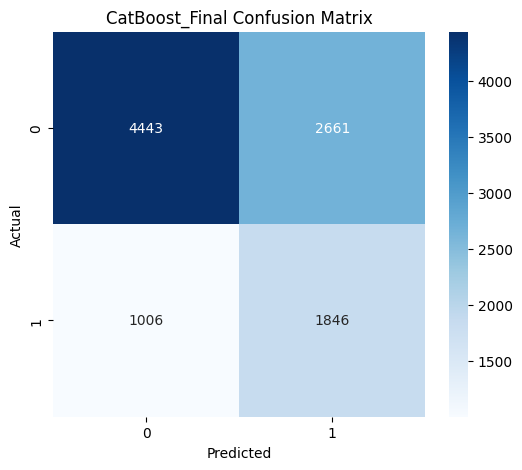

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CatBoost_Final Confusion Matrix')

plt.savefig('../../../asset/graph/catboost/CatBoost_Final_Confusion_Matrix.png', dpi=300, bbox_inches='tight')

plt.show()

##### ROC-AUC 커브

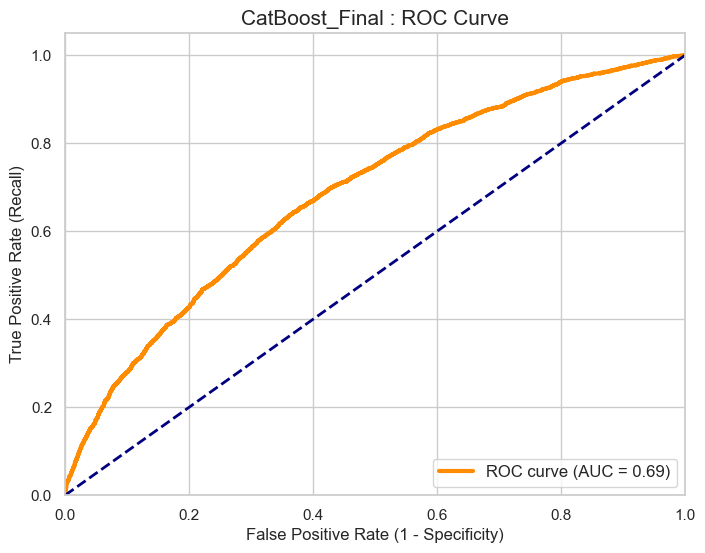

0.6857904757843398


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

pred_proba = final_model.predict_proba(X_test)

# 스타일 설정
sns.set_theme(style="whitegrid")

# ROC 계산
fpr, tpr, thresholds = roc_curve(y_test, pred_proba[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 축 범위 및 라벨 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('CatBoost_Final : ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

plt.savefig('../../../asset/graph/catboost/CatBoost_Final_ROC_curve.png', dpi=300, bbox_inches='tight')

plt.show()

print(roc_auc)

##### Feature 중요도 출력

In [17]:
final_model.feature_importances_

fesat_impt_ser = pd.Series(final_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
fesat_impt_ser

MonthsInService         10.315469
PercChangeMinutes        7.742529
CurrentEquipmentDays     7.691764
MonthlyMinutes           7.082652
TotalRecurringCharge     6.072659
                          ...    
Prizm_Other              0.053292
Occ_Student              0.046300
Occ_Clerical             0.033659
NonUSTravel              0.023864
Occ_Homemaker            0.000000
Length: 66, dtype: float64

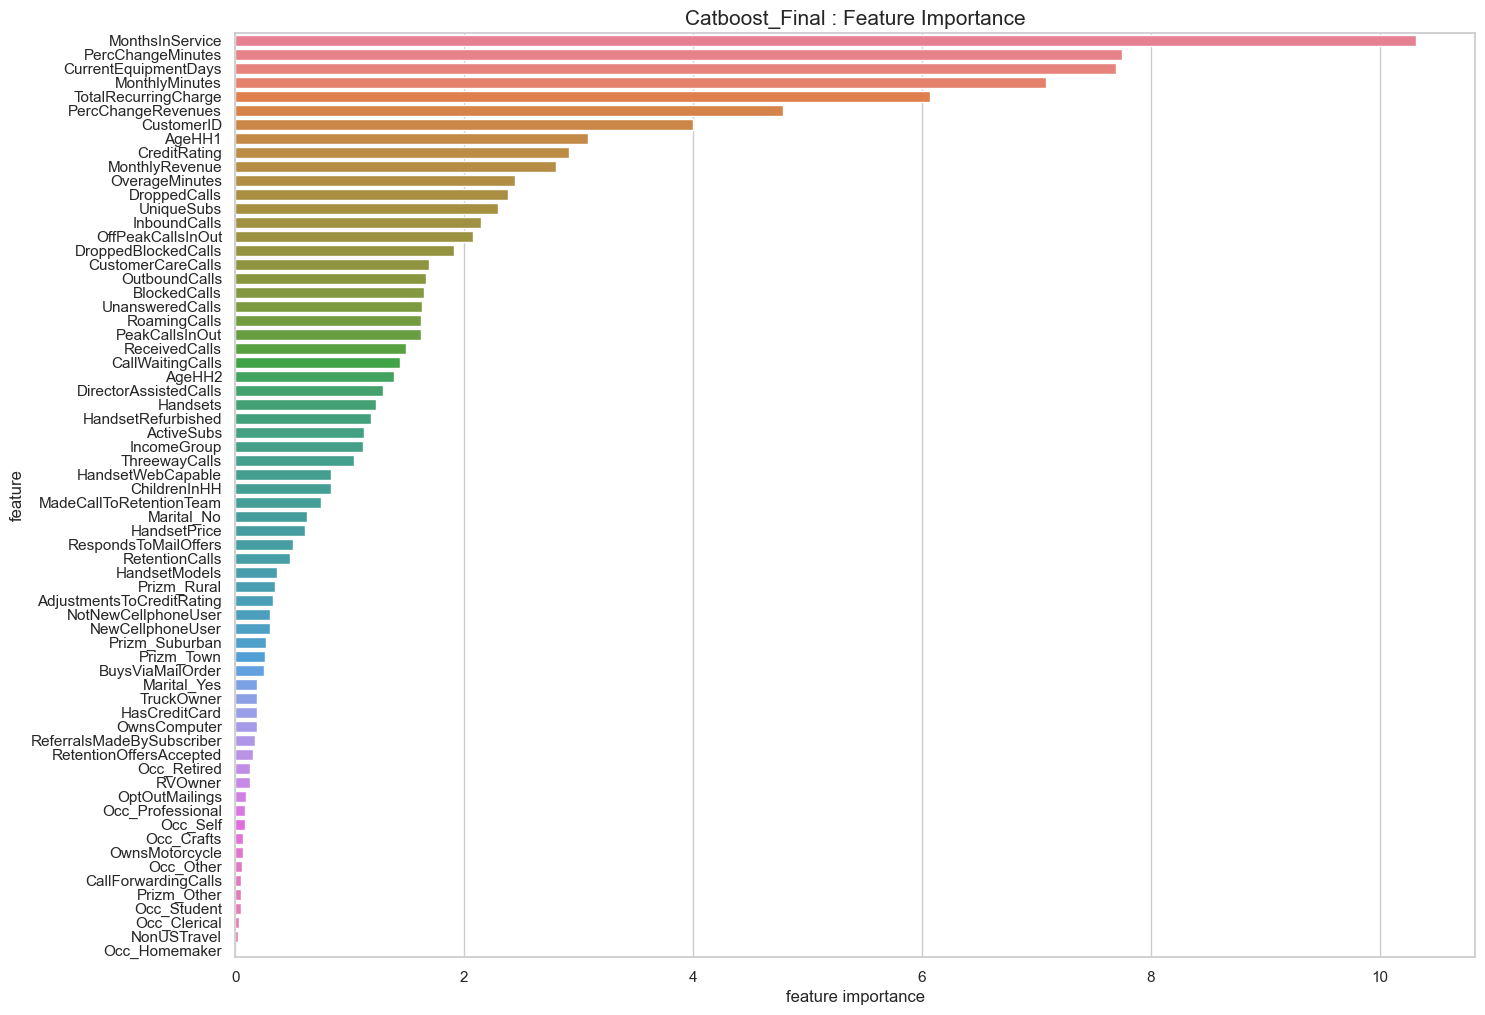

In [18]:
plt.figure(figsize=(16,12))
sns.barplot(
    x=fesat_impt_ser,
    y=fesat_impt_ser.index,
    hue=fesat_impt_ser.index,
)
plt.xlabel('feature importance')
plt.ylabel('feature')
plt.title('Catboost_Final : Feature Importance', fontsize=15)

plt.savefig('../../../asset/graph/catboost/Catboost_Final_feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()

### [추가] Threshold를 낮추었을 때 Precision, Recall, F1-Score 변화

In [19]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

# 1. 1이 될 확률(Positive Probability)만 추출
probs = final_model.predict_proba(X_test)[:, 1]

# 2. 테스트할 임계값 리스트 생성 (0.1 부터 0.9까지 0.05 단위)
thresholds = np.arange(0.1, 0.9, 0.05)

best_threshold = 0.5
best_f1 = 0

print(f"{'Threshold':<10} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 60)

# 3. 각 임계값마다 지표 계산
for th in thresholds:
    # 확률이 th 이상이면 1, 아니면 0으로 변환
    preds_binary = np.where(probs >= th, 1, 0)
    
    acc = accuracy_score(y_test, preds_binary)
    prec = precision_score(y_test, preds_binary, zero_division=0)
    rec = recall_score(y_test, preds_binary)
    f1 = f1_score(y_test, preds_binary)
    
    print(f"{th:<10.2f} | {acc:<10.4f} | {prec:<10.4f} | {rec:<10.4f} | {f1:<10.4f}")
    
    # 최고 F1-score 업데이트
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th

print("-" * 60)
print(f"Best Threshold based on F1: {best_threshold:.2f} (F1: {best_f1:.4f})")

Threshold  | Accuracy   | Precision  | Recall     | F1-Score  
------------------------------------------------------------
0.10       | 0.2876     | 0.2867     | 0.9996     | 0.4456    
0.15       | 0.3014     | 0.2903     | 0.9954     | 0.4495    
0.20       | 0.3305     | 0.2973     | 0.9807     | 0.4563    
0.25       | 0.3725     | 0.3085     | 0.9586     | 0.4668    
0.30       | 0.4193     | 0.3221     | 0.9299     | 0.4785    
0.35       | 0.4618     | 0.3343     | 0.8864     | 0.4855    
0.40       | 0.5173     | 0.3549     | 0.8377     | 0.4985    
0.45       | 0.5682     | 0.3742     | 0.7549     | 0.5004    
0.50       | 0.6317     | 0.4096     | 0.6473     | 0.5017    
0.55       | 0.6789     | 0.4450     | 0.4895     | 0.4662    
0.60       | 0.7135     | 0.5000     | 0.3454     | 0.4085    
0.65       | 0.7277     | 0.5617     | 0.2251     | 0.3214    
0.70       | 0.7270     | 0.6201     | 0.1213     | 0.2029    
0.75       | 0.7216     | 0.6587     | 0.0582     | 0.107

In [20]:
# 1. 기본 Threshold(0.5)일 때의 예측
preds_default = final_model.predict(X_test) 

# 2. Threshold를 0.3으로 낮추기 (조금만 1 같아도 1로 예측해버림)
final_model.set_probability_threshold(best_threshold)

# 3. 변경된 Threshold로 다시 예측
preds_custom = final_model.predict(X_test)

In [21]:
print(classification_report(y_test, preds_custom))

              precision    recall  f1-score   support

           0       0.82      0.63      0.71      7104
           1       0.41      0.65      0.50      2852

    accuracy                           0.63      9956
   macro avg       0.61      0.64      0.60      9956
weighted avg       0.70      0.63      0.65      9956



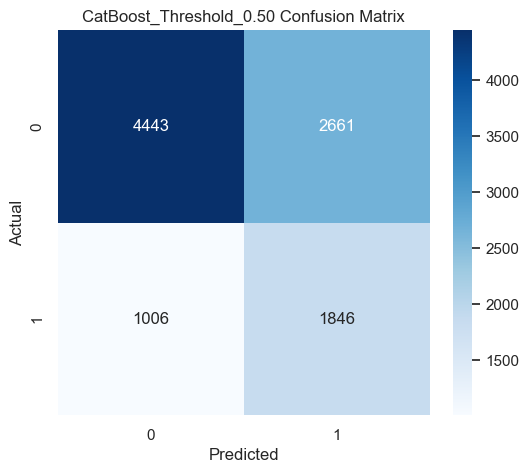

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, preds_custom)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'CatBoost_Threshold_{best_threshold:.2f} Confusion Matrix')

plt.savefig(f'../../../asset/graph/catboost/CatBoost_Threshold_{best_threshold:.2f}_Confusion_Matrix.png', dpi=300, bbox_inches='tight')

plt.show()